# Credit Risk Dataset — Exploratory Data Analysis & Cleaning

**Dataset:** `credit_risk_dataset.csv`  
**Rows:** 32,581 | **Columns:** 12  
**Target:** `loan_status` (0 = No Default, 1 = Default)

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Plot settings
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (10, 5)

print('Libraries loaded successfully.')

Libraries loaded successfully.


## 2. Load Data

In [2]:
df = pd.read_csv('../data/raw/credit_risk_dataset.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (32581, 12)


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


## 3. Basic Information

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [4]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [5]:
# Categorical columns summary
cat_cols = df.select_dtypes(include='object').columns.tolist()
print(f'Categorical columns: {cat_cols}\n')
for col in cat_cols:
    print(f'{col}: {df[col].unique().tolist()}')

Categorical columns: ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']

person_home_ownership: ['RENT', 'OWN', 'MORTGAGE', 'OTHER']
loan_intent: ['PERSONAL', 'EDUCATION', 'MEDICAL', 'VENTURE', 'HOMEIMPROVEMENT', 'DEBTCONSOLIDATION']
loan_grade: ['D', 'B', 'C', 'A', 'E', 'F', 'G']
cb_person_default_on_file: ['Y', 'N']


## 4. Missing Value Analysis

                   Missing Count  Missing %
loan_int_rate               3116       9.56
person_emp_length            895       2.75


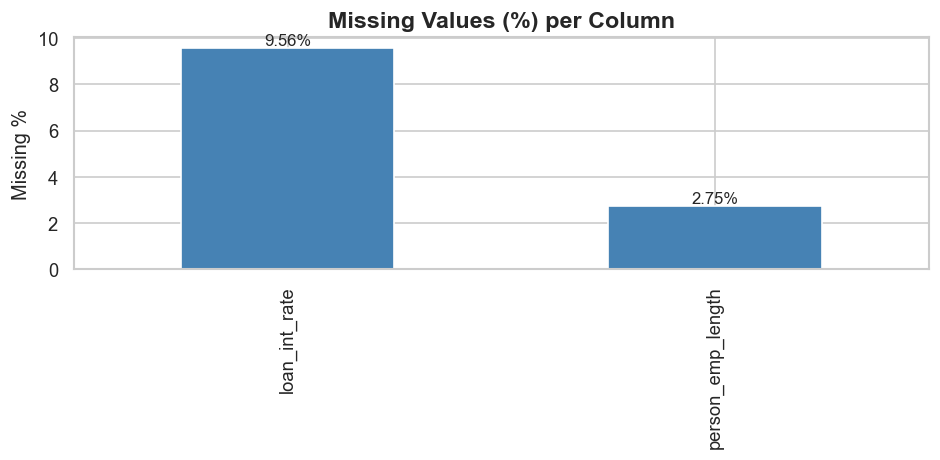

In [6]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)
print(missing_df)

# Visualise
fig, ax = plt.subplots(figsize=(8, 4))
missing_df['Missing %'].plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Missing Values (%) per Column', fontsize=14, fontweight='bold')
ax.set_ylabel('Missing %')
ax.set_xlabel('')
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}%', (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()

## 5. Target Variable Analysis

             Count  Percentage
loan_status                   
0            25473       78.18
1             7108       21.82


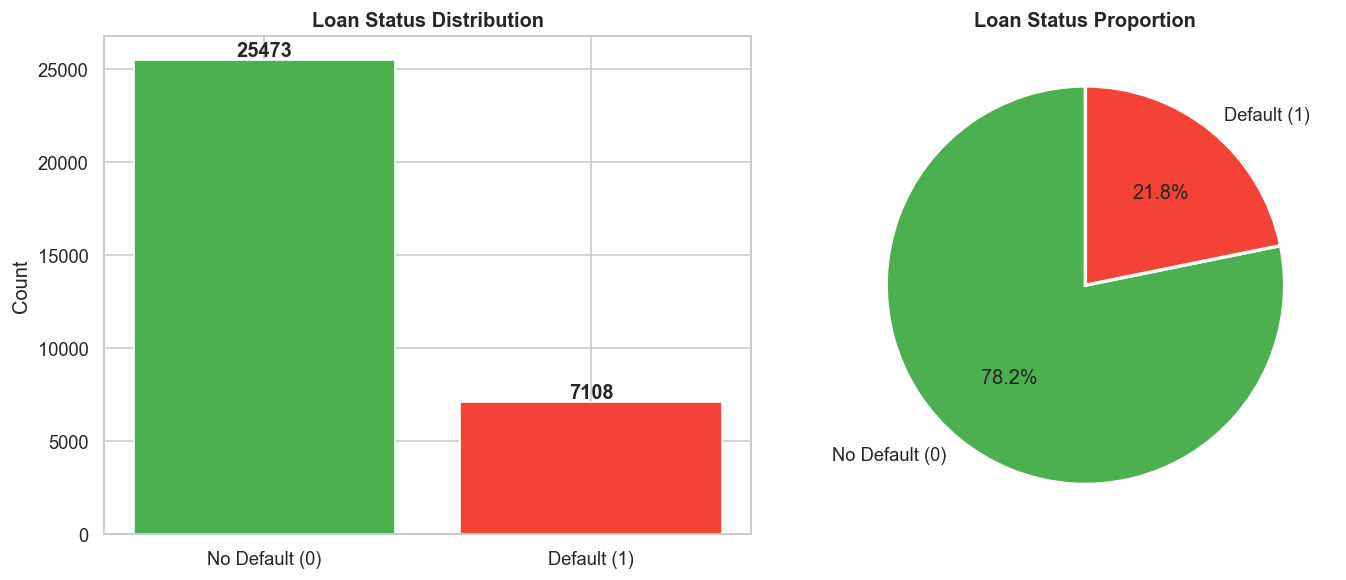

In [7]:
counts = df['loan_status'].value_counts()
pcts   = df['loan_status'].value_counts(normalize=True) * 100
print(pd.DataFrame({'Count': counts, 'Percentage': pcts.round(2)}))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
colors = ['#4CAF50', '#F44336']
axes[0].bar(['No Default (0)', 'Default (1)'], counts.values, color=colors, edgecolor='white')
axes[0].set_title('Loan Status Distribution', fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 200, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(counts.values, labels=['No Default (0)', 'Default (1)'],
            autopct='%1.1f%%', colors=colors, startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Loan Status Proportion', fontweight='bold')

plt.tight_layout()
plt.show()

## 6. Numerical Feature Distributions

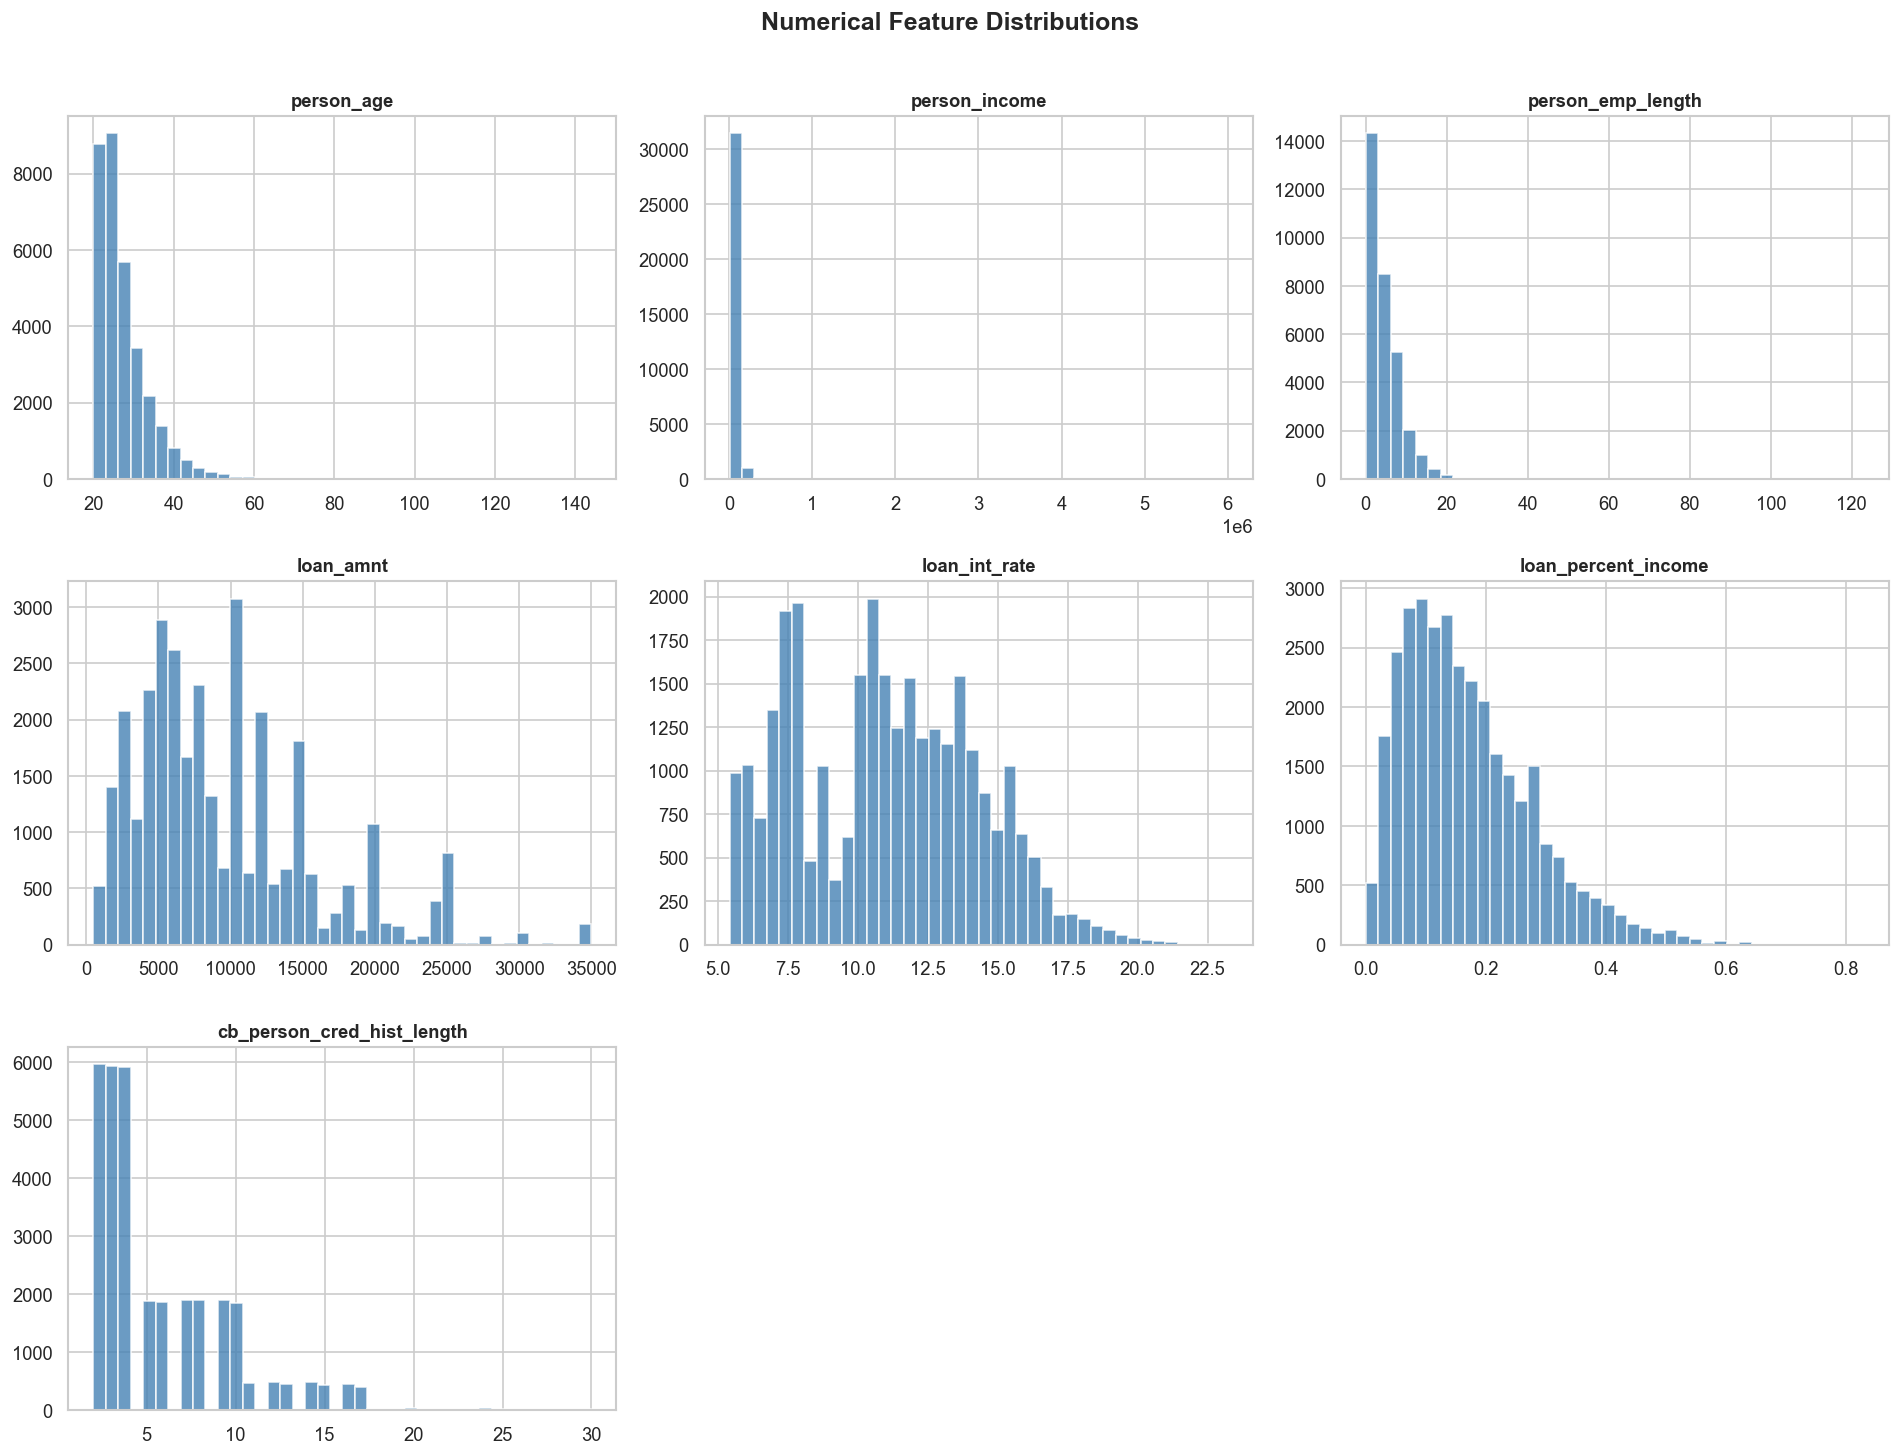

In [8]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()
num_cols = [c for c in num_cols if c != 'loan_status']

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    ax = axes[i]
    df[col].hist(bins=40, ax=ax, color='steelblue', edgecolor='white', alpha=0.8)
    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.set_xlabel('')

# Hide empty subplots
for j in range(len(num_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Numerical Feature Distributions', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 7. Outlier Detection

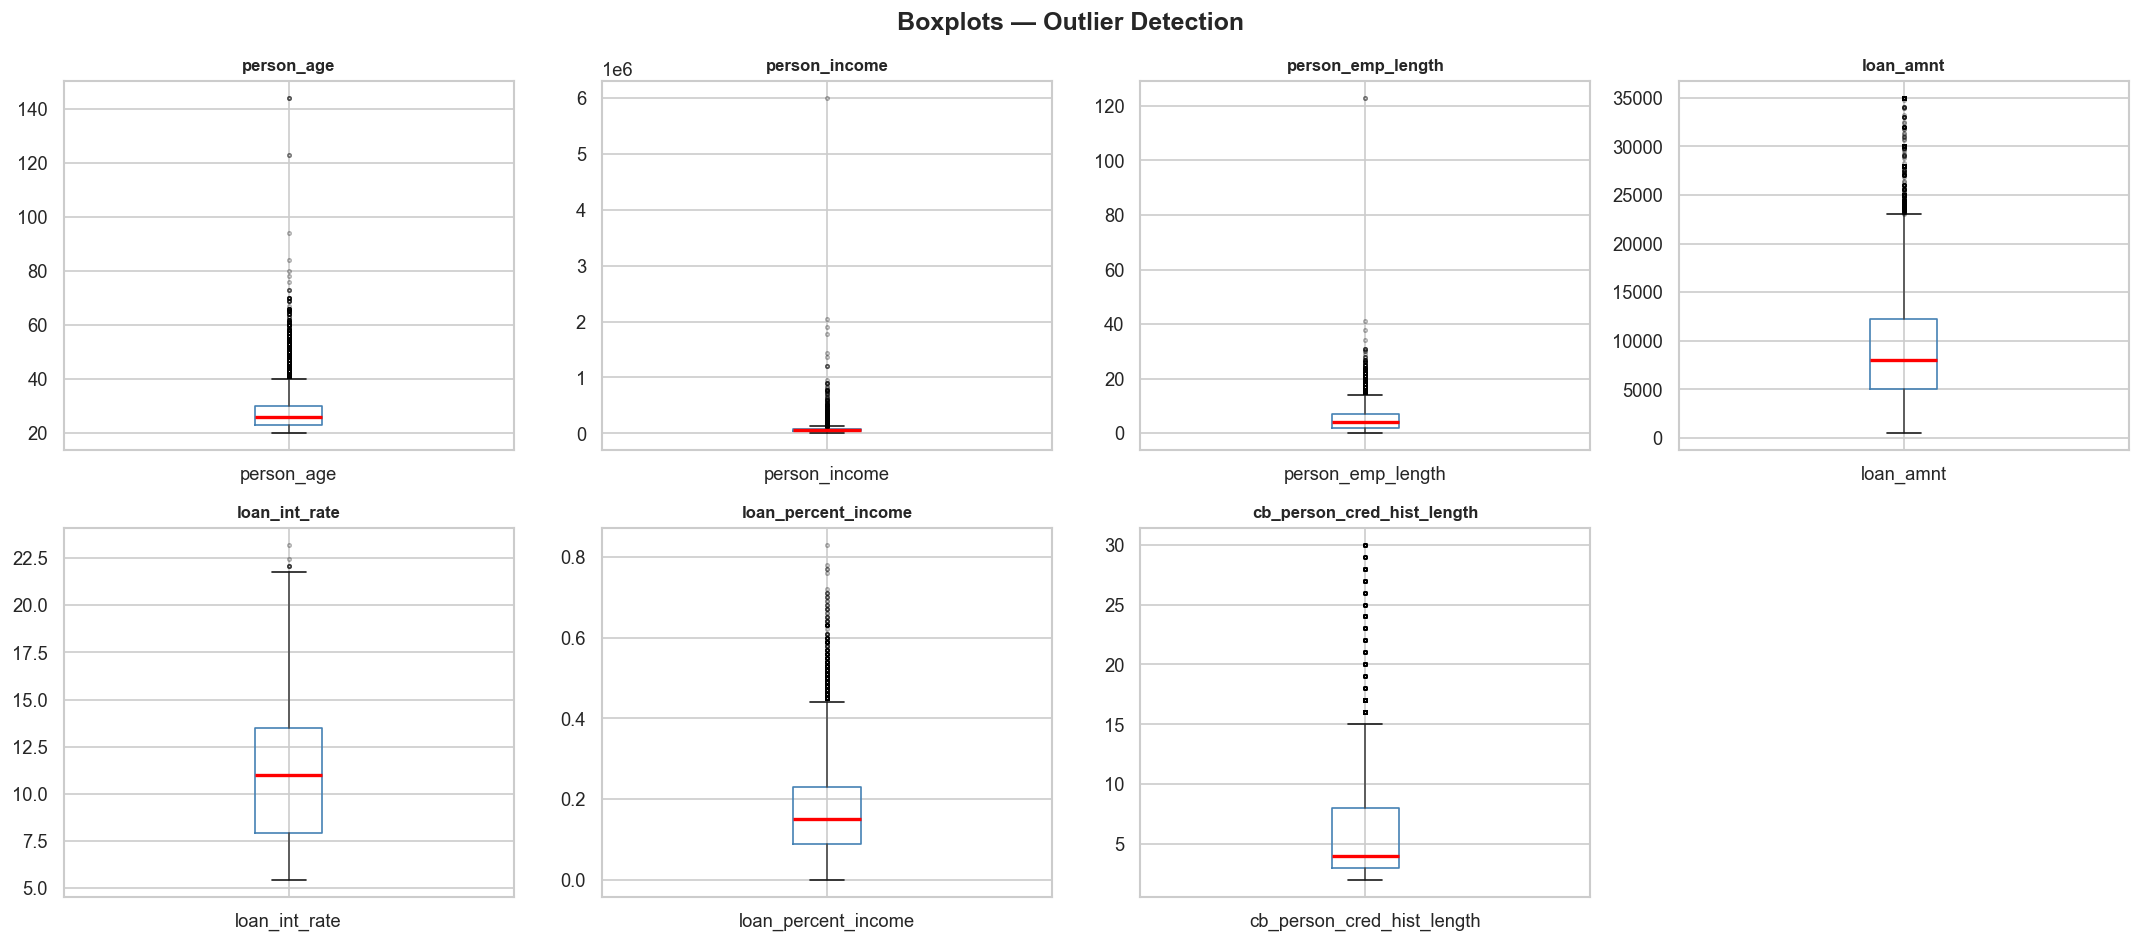


IQR-based outlier counts per feature:
  person_age: 1494 outliers (4.59%)
  person_income: 1484 outliers (4.55%)
  person_emp_length: 853 outliers (2.62%)
  loan_amnt: 1689 outliers (5.18%)
  loan_int_rate: 6 outliers (0.02%)
  loan_percent_income: 651 outliers (2.00%)
  cb_person_cred_hist_length: 1142 outliers (3.51%)


In [9]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    ax = axes[i]
    df.boxplot(column=col, ax=ax, vert=True,
               boxprops=dict(color='steelblue'),
               medianprops=dict(color='red', linewidth=2),
               flierprops=dict(marker='o', markersize=2, alpha=0.3))
    ax.set_title(col, fontsize=10, fontweight='bold')

for j in range(len(num_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Boxplots — Outlier Detection', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

# IQR-based outlier counts
print('\nIQR-based outlier counts per feature:')
for col in num_cols:
    Q1, Q3 = df[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)]
    print(f'  {col}: {len(outliers)} outliers ({len(outliers)/len(df)*100:.2f}%)')

## 8. Categorical Feature Analysis

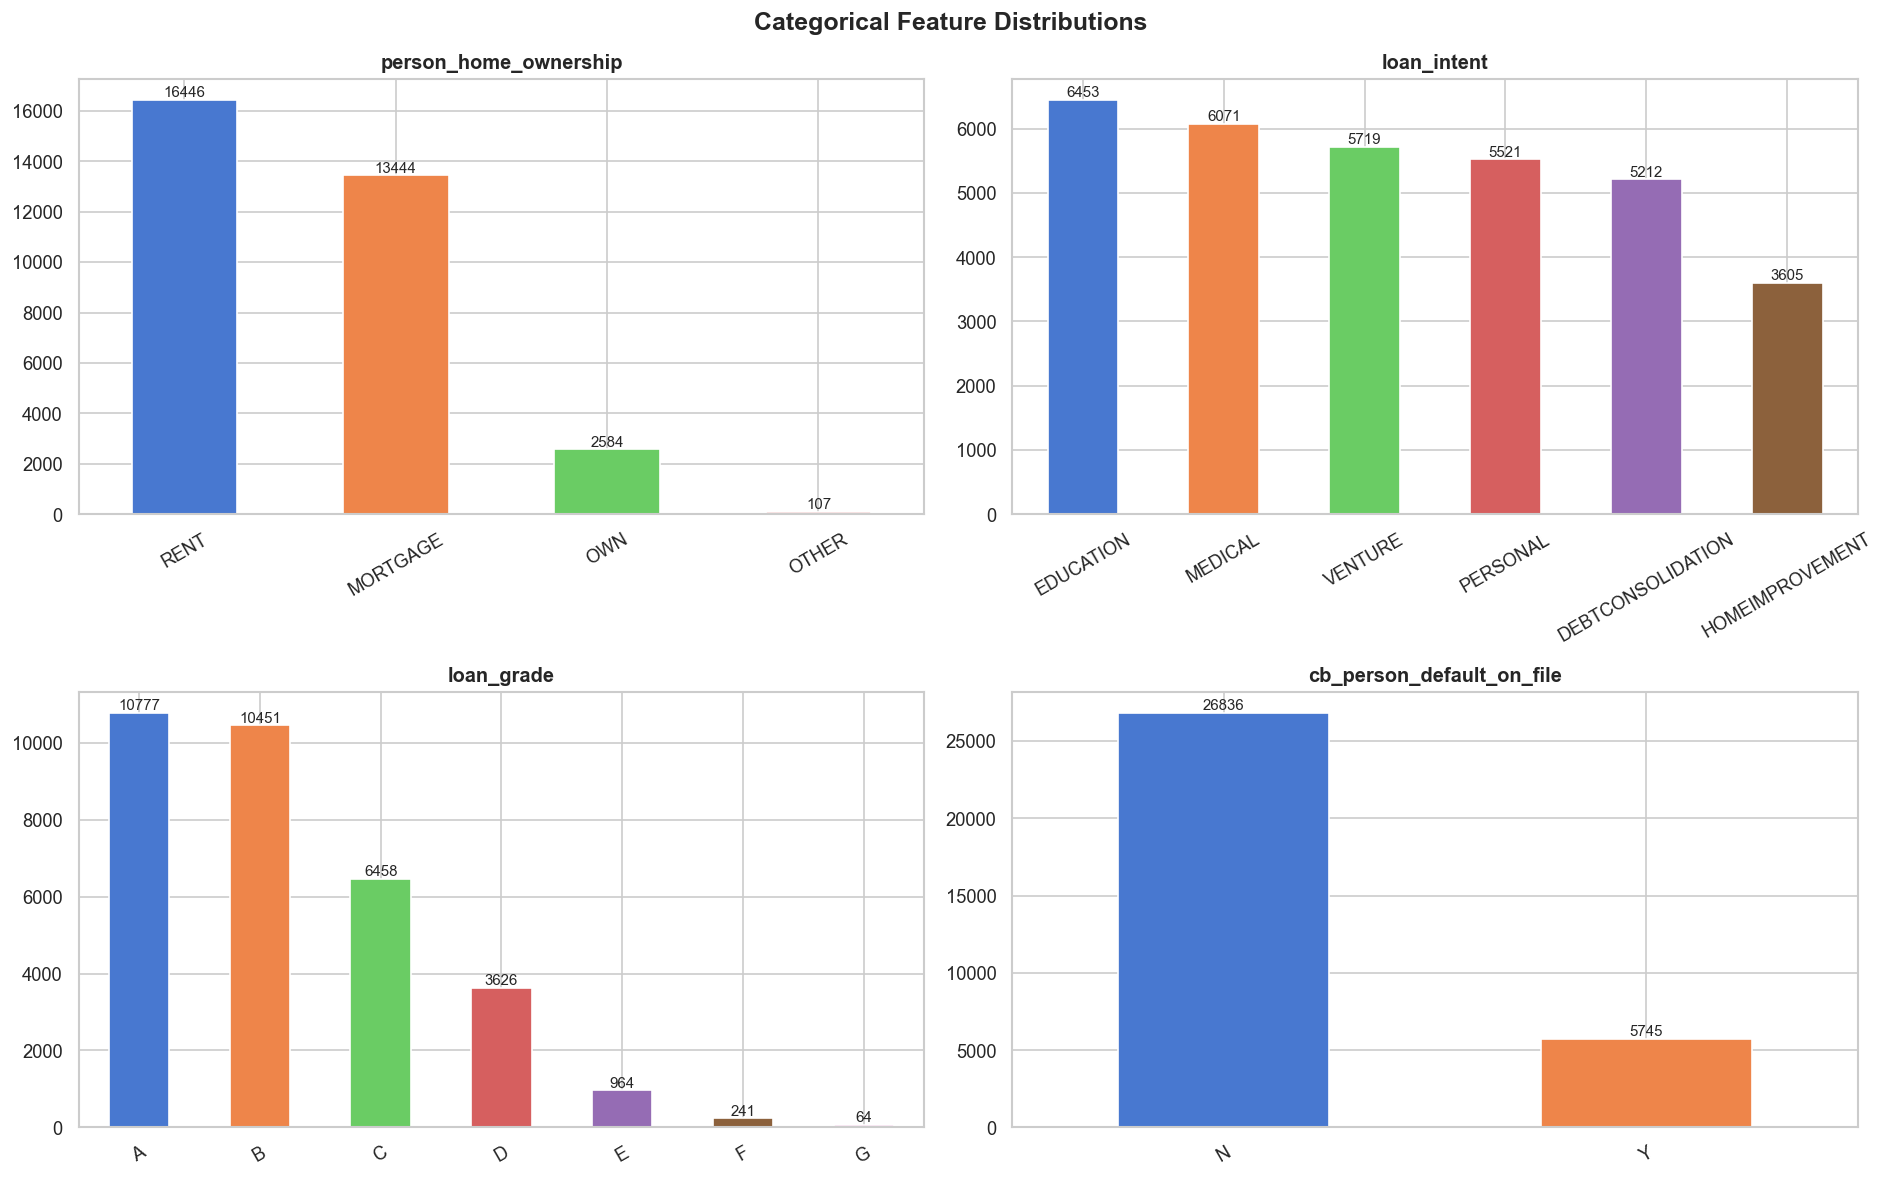

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    ax = axes[i]
    vc = df[col].value_counts()
    vc.plot(kind='bar', ax=ax, edgecolor='white', color=sns.color_palette('muted', len(vc)))
    ax.set_title(f'{col}', fontsize=12, fontweight='bold')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30)
    for p in ax.patches:
        ax.annotate(str(int(p.get_height())), (p.get_x() + p.get_width()/2, p.get_height()),
                    ha='center', va='bottom', fontsize=9)

plt.suptitle('Categorical Feature Distributions', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Default Rate by Categorical Features

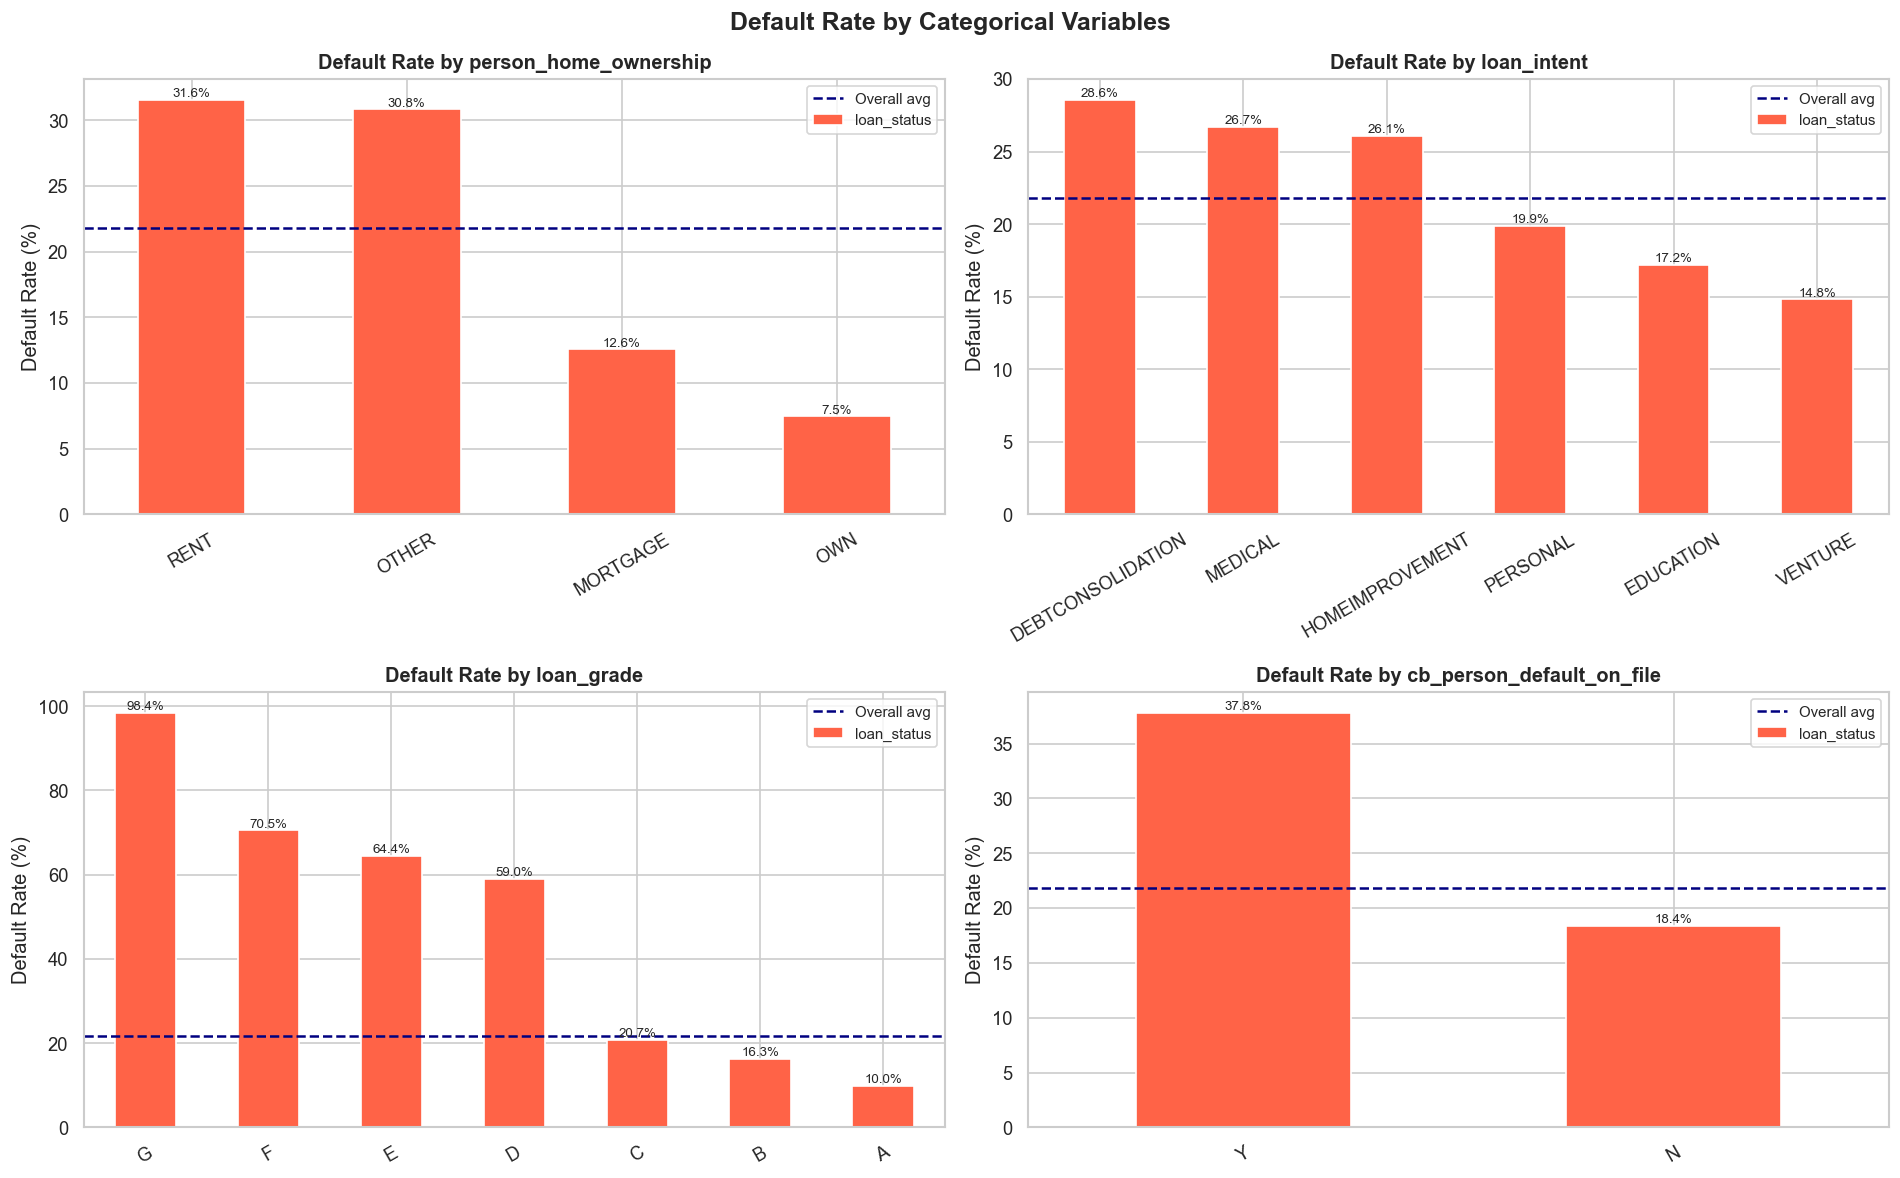

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    ax = axes[i]
    default_rate = df.groupby(col)['loan_status'].mean().sort_values(ascending=False) * 100
    default_rate.plot(kind='bar', ax=ax, color='tomato', edgecolor='white')
    ax.set_title(f'Default Rate by {col}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Default Rate (%)')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30)
    ax.axhline(df['loan_status'].mean()*100, ls='--', color='navy', lw=1.5, label='Overall avg')
    ax.legend(fontsize=9)
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width()/2, p.get_height()),
                    ha='center', va='bottom', fontsize=8)

plt.suptitle('Default Rate by Categorical Variables', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## 10. Numerical Features vs Loan Status

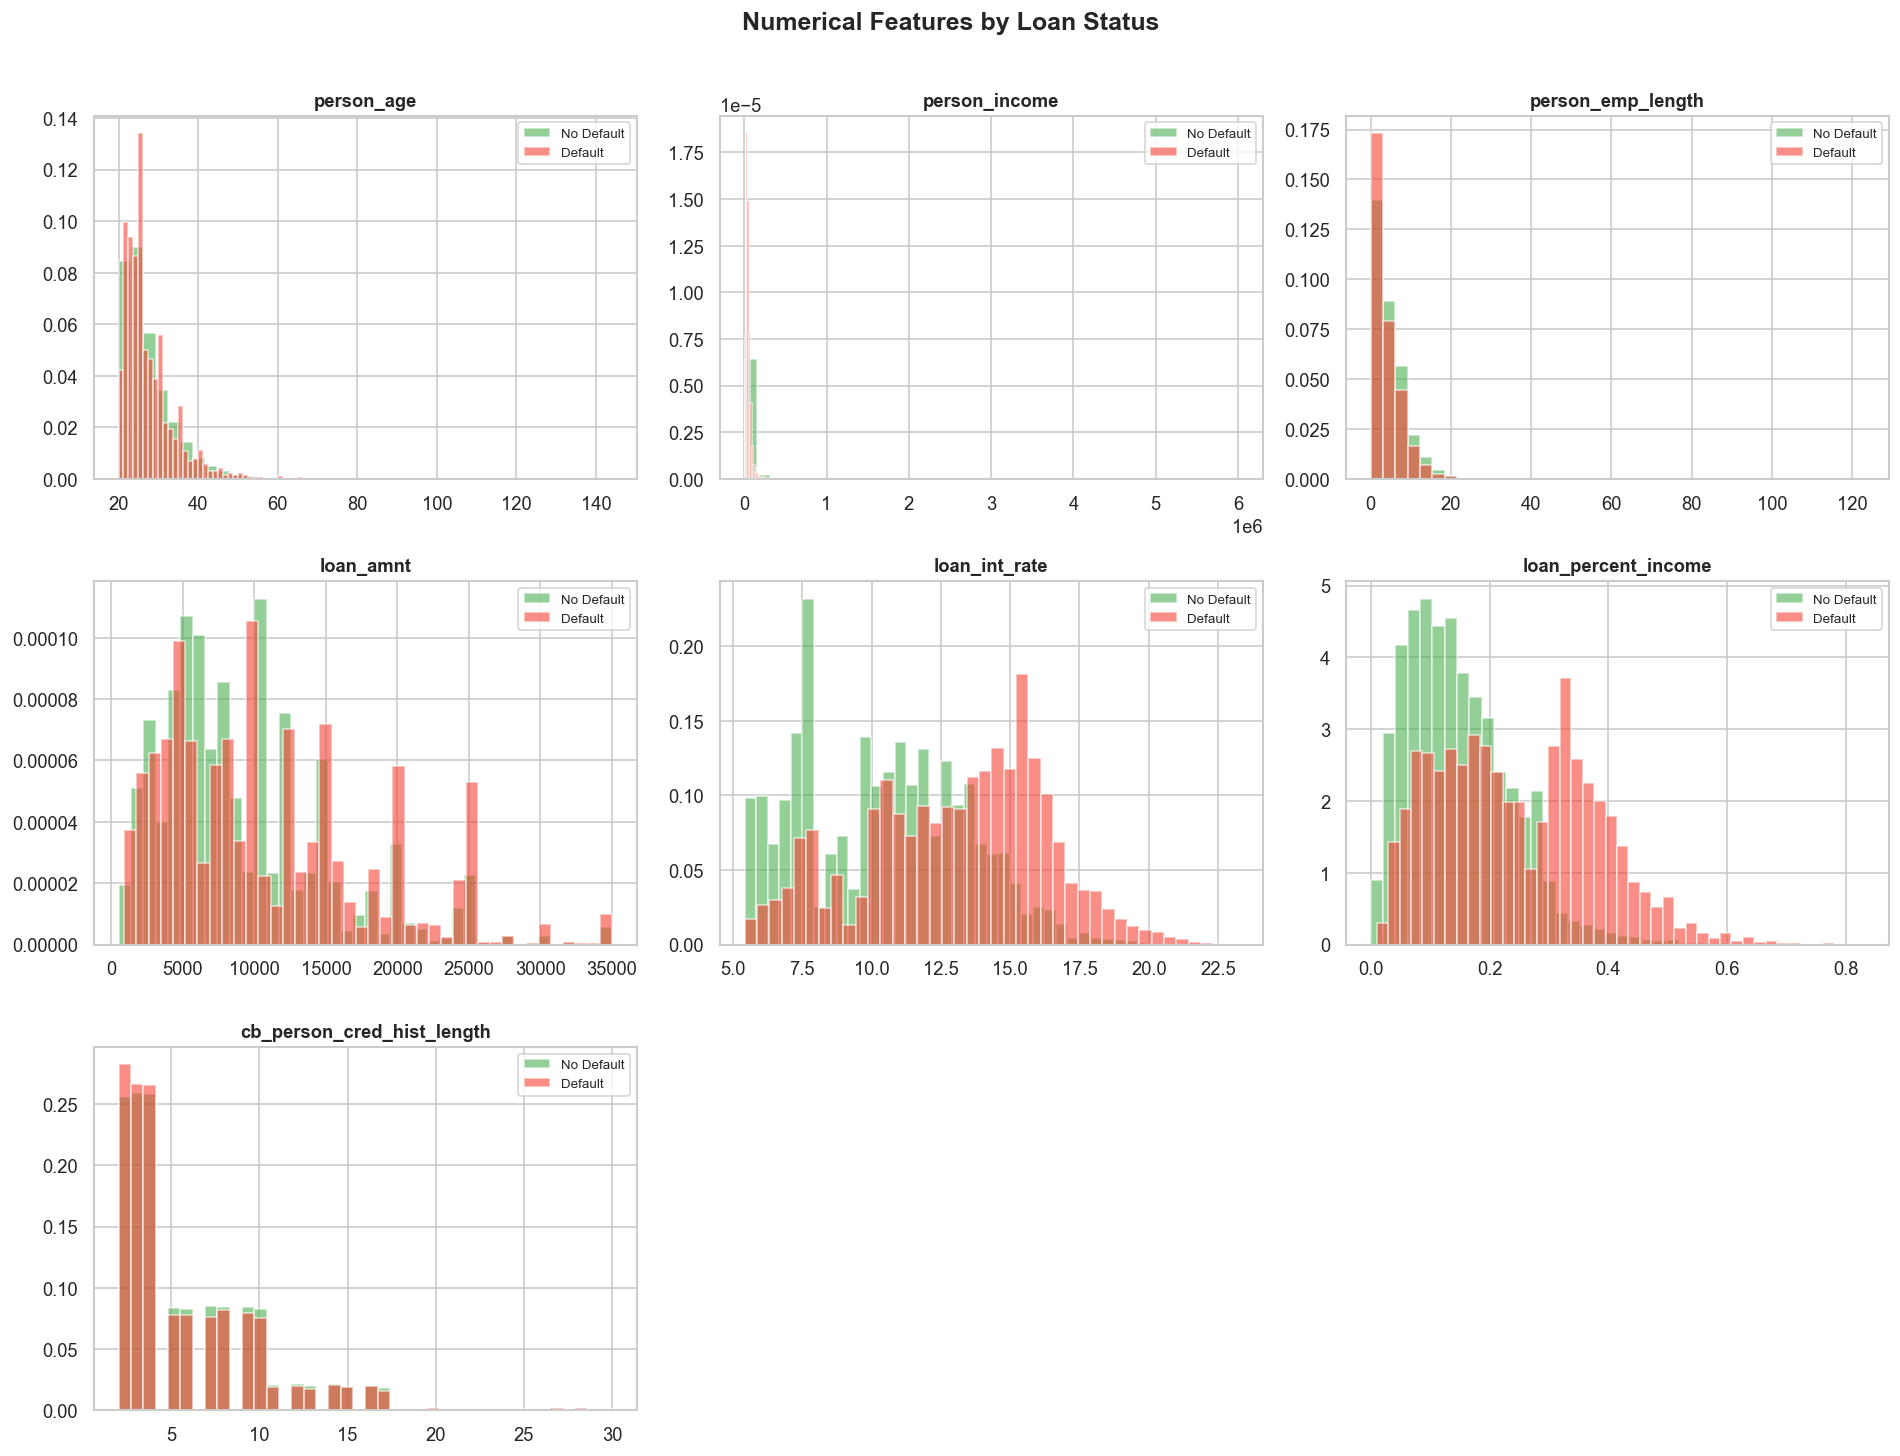

In [12]:
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    ax = axes[i]
    for status, color, label in [(0, '#4CAF50', 'No Default'), (1, '#F44336', 'Default')]:
        df[df['loan_status'] == status][col].hist(bins=40, ax=ax, alpha=0.6,
                                                   color=color, label=label, density=True)
    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.legend(fontsize=8)

for j in range(len(num_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Numerical Features by Loan Status', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 11. Correlation Analysis

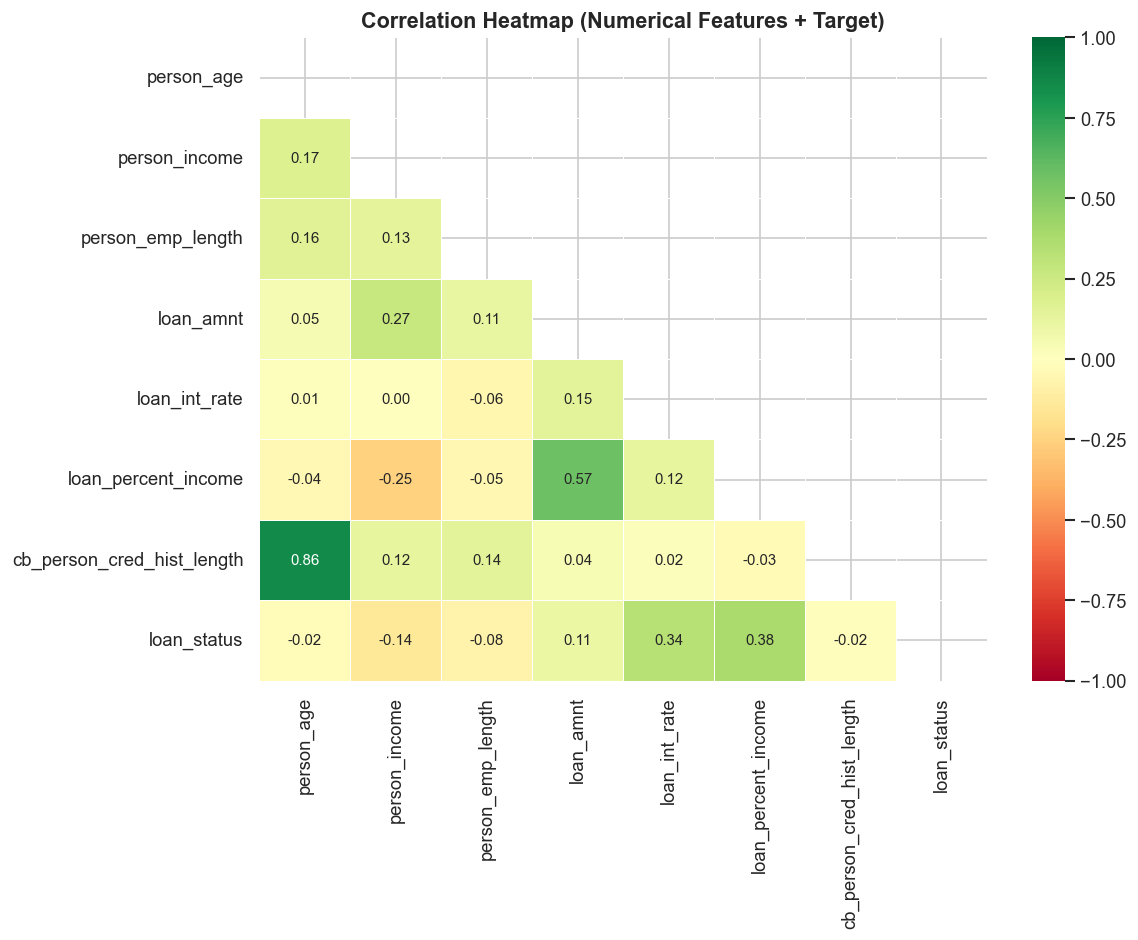


Correlation with loan_status:
loan_percent_income           0.379
loan_int_rate                 0.335
loan_amnt                     0.105
cb_person_cred_hist_length   -0.016
person_age                   -0.022
person_emp_length            -0.082
person_income                -0.144
Name: loan_status, dtype: float64


In [13]:
corr = df[num_cols + ['loan_status']].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn', ax=ax,
            linewidths=0.5, mask=mask, vmin=-1, vmax=1,
            annot_kws={'size': 9})
ax.set_title('Correlation Heatmap (Numerical Features + Target)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nCorrelation with loan_status:')
print(corr['loan_status'].drop('loan_status').sort_values(ascending=False).round(3))

## 12. Pairplot (Key Features)

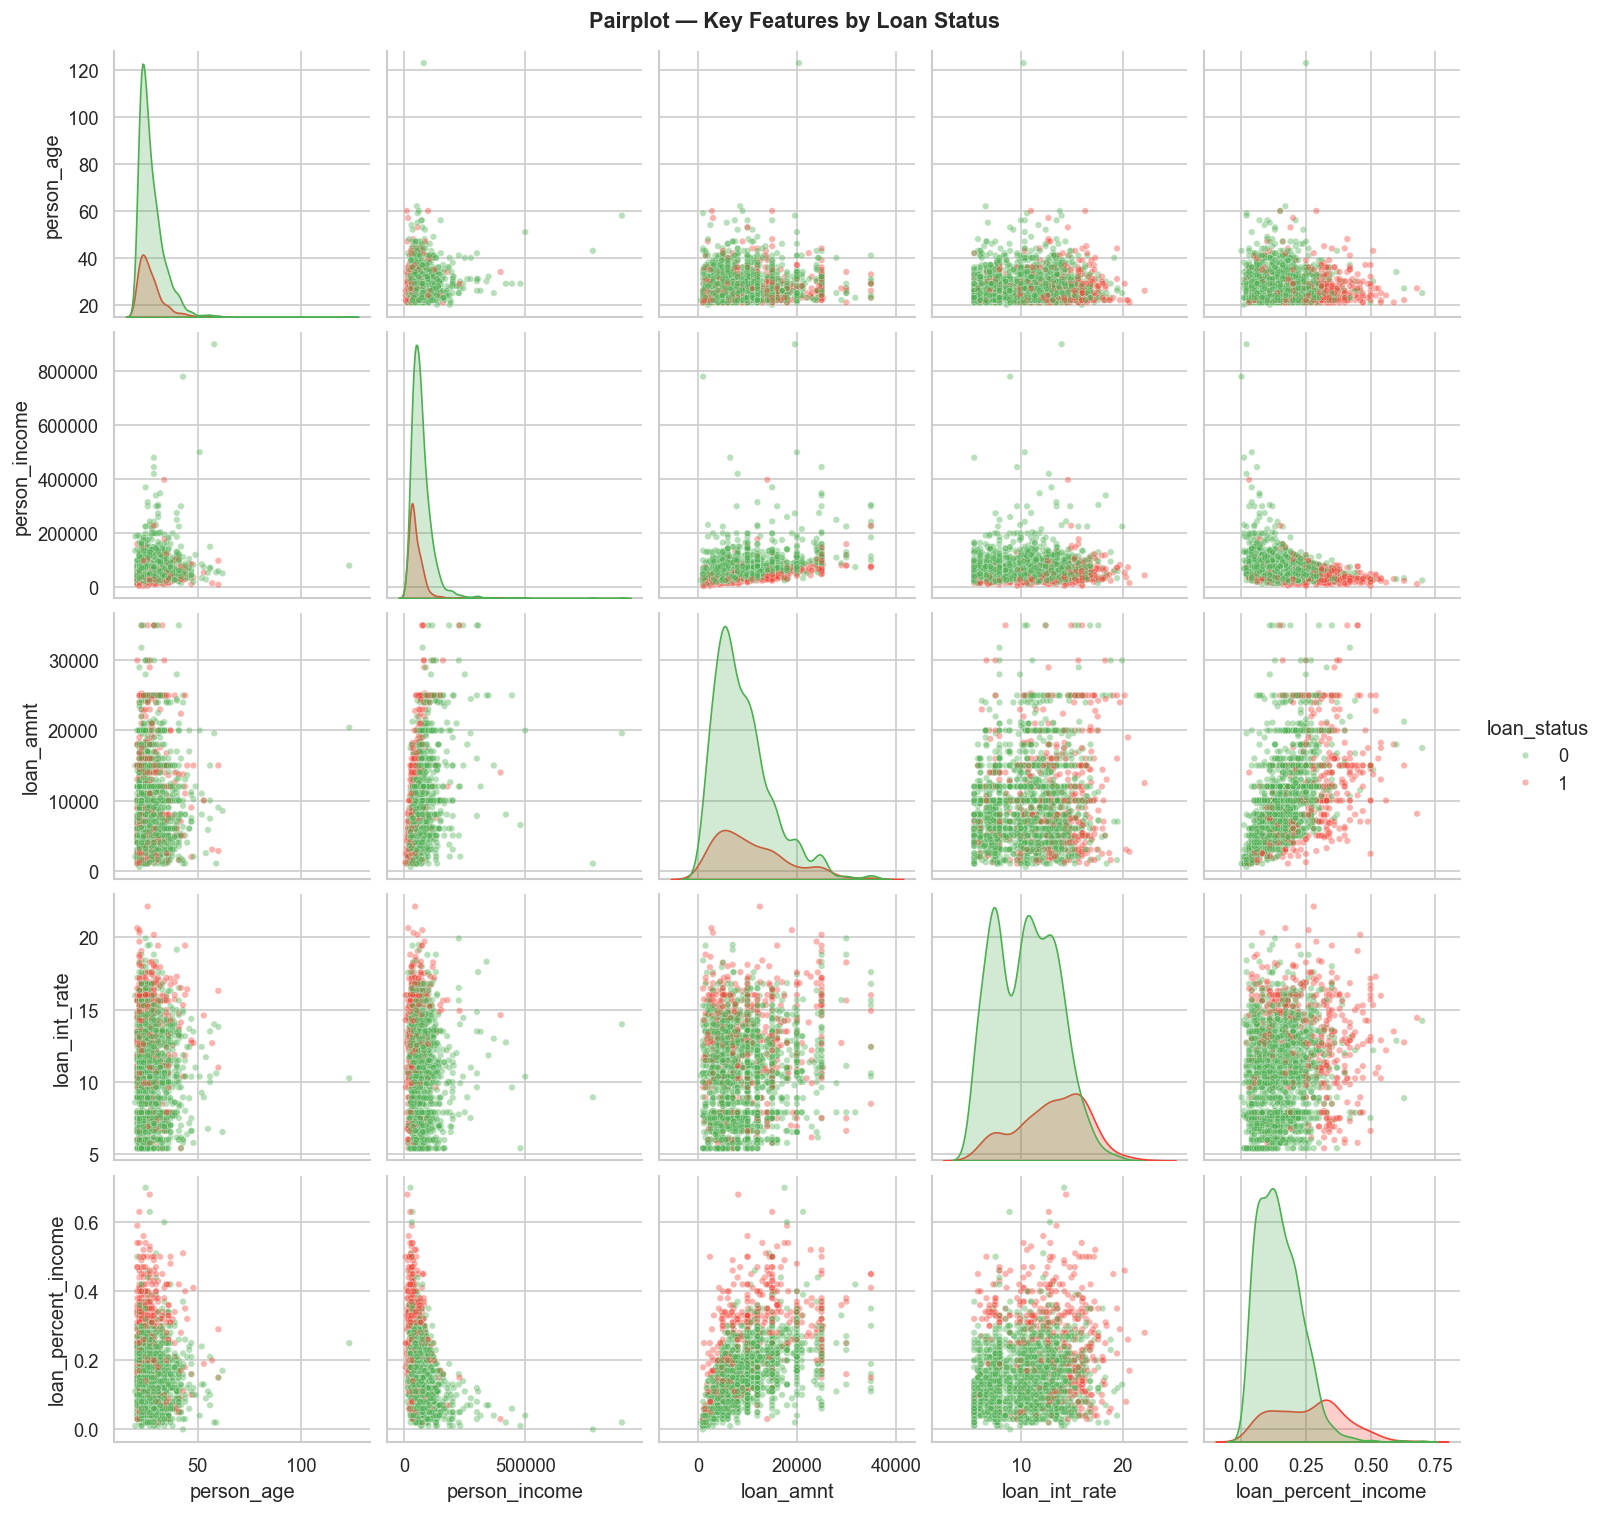

In [14]:
key_features = ['person_age', 'person_income', 'loan_amnt', 'loan_int_rate',
                'loan_percent_income', 'loan_status']
sample = df[key_features].dropna().sample(n=2000, random_state=42)

g = sns.pairplot(sample, hue='loan_status', plot_kws={'alpha': 0.4, 's': 15},
                 palette={0: '#4CAF50', 1: '#F44336'},
                 diag_kind='kde')
g.figure.suptitle('Pairplot — Key Features by Loan Status', fontsize=13, fontweight='bold', y=1.01)
plt.show()

## 13. Data Cleaning

In [15]:
df_clean = df.copy()
print(f'Original shape: {df_clean.shape}')

Original shape: (32581, 12)


In [16]:
# ── 13.1 Remove duplicate rows ─────────────────────────────────────────────
dupes = df_clean.duplicated().sum()
print(f'Duplicate rows found: {dupes}')
df_clean.drop_duplicates(inplace=True)
print(f'Shape after deduplication: {df_clean.shape}')

Duplicate rows found: 165
Shape after deduplication: (32416, 12)


In [17]:
# ── 13.2 Fix unrealistic ages (age > 100 treated as data-entry errors) ─────
print(f'Rows with person_age > 100: {(df_clean.person_age > 100).sum()}')
median_age = df_clean[df_clean.person_age <= 100]['person_age'].median()
df_clean.loc[df_clean.person_age > 100, 'person_age'] = median_age
print(f'Max age after fix: {df_clean.person_age.max()}')

Rows with person_age > 100: 5
Max age after fix: 94


In [18]:
# ── 13.3 Cap unrealistic employment length (> 60 years) ────────────────────
print(f'Rows with person_emp_length > 60: {(df_clean.person_emp_length > 60).sum()}')
df_clean.loc[df_clean.person_emp_length > 60, 'person_emp_length'] = np.nan  # treat as missing
print(f'Max emp_length after cap: {df_clean.person_emp_length.max()}')

Rows with person_emp_length > 60: 2
Max emp_length after cap: 41.0


In [19]:
# ── 13.4 Impute missing values ──────────────────────────────────────────────
# person_emp_length: impute with median
emp_median = df_clean['person_emp_length'].median()
df_clean['person_emp_length'].fillna(emp_median, inplace=True)
print(f'person_emp_length missing after impute: {df_clean.person_emp_length.isnull().sum()}')

# loan_int_rate: impute with median within each loan_grade group
df_clean['loan_int_rate'] = df_clean.groupby('loan_grade')['loan_int_rate'].transform(
    lambda x: x.fillna(x.median())
)
print(f'loan_int_rate missing after grade-median impute: {df_clean.loan_int_rate.isnull().sum()}')
# Fallback: global median for any remaining NaN
df_clean['loan_int_rate'].fillna(df_clean['loan_int_rate'].median(), inplace=True)

print(f'\nTotal missing values remaining: {df_clean.isnull().sum().sum()}')

person_emp_length missing after impute: 0
loan_int_rate missing after grade-median impute: 0

Total missing values remaining: 0


In [20]:
# ── 13.5 Standardise categorical string values ──────────────────────────────
for col in cat_cols:
    df_clean[col] = df_clean[col].str.strip().str.upper()

print('Unique values after standardisation:')
for col in cat_cols:
    print(f'  {col}: {df_clean[col].unique().tolist()}')

Unique values after standardisation:
  person_home_ownership: ['RENT', 'OWN', 'MORTGAGE', 'OTHER']
  loan_intent: ['PERSONAL', 'EDUCATION', 'MEDICAL', 'VENTURE', 'HOMEIMPROVEMENT', 'DEBTCONSOLIDATION']
  loan_grade: ['D', 'B', 'C', 'A', 'E', 'F', 'G']
  cb_person_default_on_file: ['Y', 'N']


In [21]:
# ── 13.6 Cap extreme income outliers at 99th percentile ─────────────────────
income_cap = df_clean['person_income'].quantile(0.99)
print(f'99th percentile income: {income_cap:,.0f}')
before = (df_clean['person_income'] > income_cap).sum()
df_clean['person_income'] = df_clean['person_income'].clip(upper=income_cap)
print(f'Income values capped: {before}')

99th percentile income: 225,000
Income values capped: 324


In [22]:
# ── 13.7 Feature engineering ────────────────────────────────────────────────
df_clean['loan_to_income_ratio'] = (df_clean['loan_amnt'] / df_clean['person_income']).round(4)
df_clean['income_per_emp_year']  = (df_clean['person_income'] / (df_clean['person_emp_length'] + 1)).round(2)

print('New features added:')
print(df_clean[['loan_to_income_ratio', 'income_per_emp_year']].describe().round(3))

New features added:
       loan_to_income_ratio  income_per_emp_year
count             32416.000            32416.000
mean                  0.171            18850.852
std                   0.107            22146.533
min                   0.004              505.500
25%                   0.090             6800.000
50%                   0.148            11333.330
75%                   0.229            21000.000
max                   0.830           225000.000


In [23]:
# ── 13.8 Encode binary categorical columns ──────────────────────────────────
df_clean['cb_default_flag'] = (df_clean['cb_person_default_on_file'] == 'Y').astype(int)
df_clean.drop(columns=['cb_person_default_on_file'], inplace=True)

print('cb_default_flag distribution:')
print(df_clean['cb_default_flag'].value_counts())

cb_default_flag distribution:
cb_default_flag
0    26686
1     5730
Name: count, dtype: int64


In [24]:
# ── 13.9 One-hot encode remaining categoricals ──────────────────────────────
df_encoded = pd.get_dummies(
    df_clean,
    columns=['person_home_ownership', 'loan_intent', 'loan_grade'],
    drop_first=True
)
print(f'Shape after encoding: {df_encoded.shape}')
df_encoded.head(2)

Shape after encoding: (32416, 25)


,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length,loan_to_income_ratio,income_per_emp_year,...,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,loan_grade_B,loan_grade_C,loan_grade_D,loan_grade_E,loan_grade_F,loan_grade_G
0,22,59000,4.0,35000,16.02,1,0.59,3,0.5932,11800.0,...,False,False,True,False,False,False,True,False,False,False
1,21,9600,5.0,1000,11.14,0,0.10,2,0.1042,1600.0,...,False,False,False,False,True,False,False,False,False,False


## 14. Final Cleaned Dataset Summary

In [25]:
print('='*55)
print('  CLEANING SUMMARY')
print('='*55)
print(f'  Original shape      : {df.shape}')
print(f'  Cleaned shape       : {df_clean.shape}')
print(f'  Encoded shape       : {df_encoded.shape}')
print(f'  Rows removed        : {df.shape[0] - df_clean.shape[0]}')
print(f'  Missing values left : {df_clean.isnull().sum().sum()}')
print(f'  New features added  : loan_to_income_ratio, income_per_emp_year, cb_default_flag')
print('='*55)

df_clean.describe(include='all').T

  CLEANING SUMMARY
  Original shape      : (32581, 12)
  Cleaned shape       : (32416, 14)
  Encoded shape       : (32416, 25)
  Rows removed        : 165
  Missing values left : 0
  New features added  : loan_to_income_ratio, income_per_emp_year, cb_default_flag


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
person_age,32416.0,NaN,NaN,NaN,27.730102,6.210006,20.0,23.0,26.0,30.0,94.0
person_income,32416.0,NaN,NaN,NaN,64354.20277,37800.895594,4000.0,38542.0,55000.0,79218.0,225000.0
person_home_ownership,32416,4,RENT,16378,NaN,NaN,NaN,NaN,NaN,NaN,NaN
person_emp_length,32416.0,NaN,NaN,NaN,4.761538,3.983588,0.0,2.0,4.0,7.0,41.0
loan_intent,32416,6,EDUCATION,6411,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan_grade,32416,7,A,10703,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan_amnt,32416.0,NaN,NaN,NaN,9593.845632,6322.730241,500.0,5000.0,8000.0,12250.0,35000.0
loan_int_rate,32416.0,NaN,NaN,NaN,11.020159,3.21338,5.42,7.88,10.99,13.48,23.22
loan_status,32416.0,NaN,NaN,NaN,0.218688,0.413363,0.0,0.0,0.0,0.0,1.0
loan_percent_income,32416.0,NaN,NaN,NaN,0.17025,0.106812,0.0,0.09,0.15,0.23,0.83


In [26]:
# ── Save outputs ─────────────────────────────────────────────────────────────
df_clean.to_csv('credit_risk_cleaned.csv', index=False)
df_encoded.to_csv('credit_risk_encoded.csv', index=False)
print('Files saved:')
print('  credit_risk_cleaned.csv  — cleaned, with new features')
print('  credit_risk_encoded.csv  — fully encoded, model-ready')

Files saved:
  credit_risk_cleaned.csv  — cleaned, with new features
  credit_risk_encoded.csv  — fully encoded, model-ready


In [27]:
import mlflow

with mlflow.start_run(run_name="Data_Cleaning_and_Feature_Eng"):
    # Log parameters
    mlflow.log_param("rows_before", 32581)
    mlflow.log_param("rows_after", df_clean.shape[0])
    
    # Log metrics
    mlflow.log_metric("missing_values_handled", 1) 
    mlflow.log_metric("features_created", 3)
    
    # Save the cleaned data summary as an artifact
    df_clean.describe().to_csv("data_summary.csv")
    mlflow.log_artifact("data_summary.csv")
    
    print("Phase 2 metrics logged to MLflow!")

2026/05/08 12:49:25 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/05/08 12:49:25 INFO mlflow.store.db.utils: Updating database tables


Phase 2 metrics logged to MLflow!
